In [1]:
# Session 10

In [13]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

print("Sigmoid(-2):", sigmoid(-2))
print("Sigmoid(0):", sigmoid(0))
print("Sigmoid(3):", sigmoid(3))

Sigmoid(-2): 0.11920292202211755
Sigmoid(0): 0.5
Sigmoid(3): 0.9525741268224334


In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [23]:
data = {
    'likes': [100, 250, 500, 1000, 1500, 2000, 3000, 4000, 5000, 7000],
    'has_caption': [0, 1, 1, 0, 1, 1, 0, 1, 1, 1],
    'viral': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,likes,has_caption,viral
0,100,0,0
1,250,1,0
2,500,1,0
3,1000,0,0
4,1500,1,1
5,2000,1,1
6,3000,0,1
7,4000,1,1
8,5000,1,1
9,7000,1,1


In [25]:
# Features Selection
X = df[['likes', 'has_caption']]
y = df['viral']

In [27]:
# model Selection
model = LogisticRegression()
model.fit(X,y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[0.03794123 0.00010847]]
Intercept: [-47.42535466]


In [31]:
import numpy as np
import matplotlib.pyplot as plt

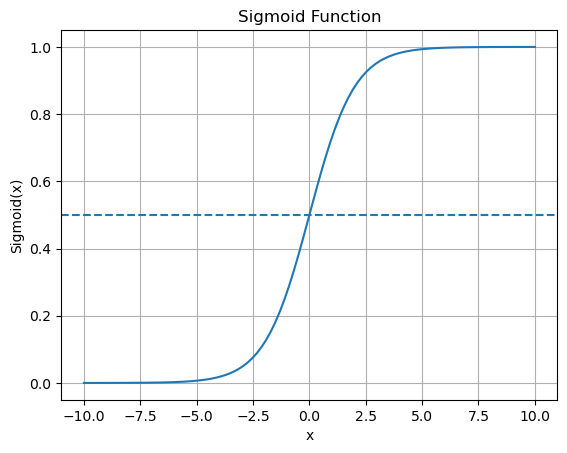

In [41]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.axhline(y=0.5, linestyle='--')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

In [73]:
def classify_viral(probability, threshold=0.5):
    if probability >= threshold:
        return "Viral"
    else:
        return "Not Viral"
        
# Using 0.5
print(classify_viral(0.2))
print(classify_viral(0.6))
print(classify_viral(0.8))

# Using 0.7
print(classify_viral(0.2, 0.7))
print(classify_viral(0.6, 0.7))
print(classify_viral(0.8, 0.7))

Not Viral
Viral
Viral
Not Viral
Not Viral
Viral


In [75]:
# Session 11

In [60]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [62]:
data = {
    "review": [
        "Excellent product and very good quality",
        "Amazing product I loved it",
        "Very happy with this purchase",
        "Good quality and fast delivery",
        "Product is awesome",
        "Very bad product",
        "Worst product ever",
        "Poor quality product",
        "Not worth the money",
        "Very disappointed with this product"
    ],
    "label": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative"
    ]
}

df = pd.DataFrame(data)
df

,review,label
0,Excellent product and very good quality,positive
1,Amazing product I loved it,positive
2,Very happy with this purchase,positive
3,Good quality and fast delivery,positive
4,Product is awesome,positive
5,Very bad product,negative
6,Worst product ever,negative
7,Poor quality product,negative
8,Not worth the money,negative
9,Very disappointed with this product,negative


In [66]:
X=df['review']
y=df['label']

In [68]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [84]:
# Vectorization
Vectorizer=CountVectorizer()
X_train_count=Vectorizer.fit_transform(X_train)
X_test_count=Vectorizer.transform(X_test)

In [88]:
# Model Seletion
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_count.toarray(),y_train)
y_pred=model.predict(X_test_count.toarray())

In [122]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy",accuracy*100)
print("Actual",y_test.values)
print("prediction",y_pred)

Accuracy 66.66666666666666
Actual ['negative' 'positive' 'negative']
prediction ['negative' 'negative' 'negative']


In [127]:
new_review = ["The product quality is excellent and amazing"]
new_review_count = Vectorizer.transform(new_review)
prediction = model.predict(new_review_count.toarray())

print("Review:", new_review[0])
print("Prediction:", prediction[0])

Review: The product quality is excellent and amazing
Prediction: positive


In [129]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [131]:
data = {
    "tempo": [120, 125, 130, 128, 135, 80, 85, 90, 75, 88],
    "danceability": [0.85, 0.90, 0.80, 0.88, 0.92, 0.35, 0.40, 0.45, 0.30, 0.38],
    "energy": [0.90, 0.95, 0.88, 0.92, 0.96, 0.30, 0.35, 0.40, 0.25, 0.32],
    "playlist": [
        "workout", "workout", "workout", "workout", "workout",
        "chill", "chill", "chill", "chill", "chill"
    ]
}

df = pd.DataFrame(data)

In [133]:
X = df[["tempo", "danceability", "energy"]]
y = df["playlist"]

In [145]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [147]:
# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [171]:
# model selection
knn_euclidean = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_manhattan = KNeighborsClassifier(
    n_neighbors=3,
    metric="manhattan"
)
knn_euclidean.fit(X_train, y_train)
knn_manhattan.fit(X_train, y_train)
pred_euclidean = knn_euclidean.predict(X_test)
pred_manhattan = knn_manhattan.predict(X_test)

In [173]:
# Accuracy
accuracy_euclidean = accuracy_score(y_test, pred_euclidean)
accuracy_manhattan = accuracy_score(y_test, pred_manhattan)

print("Euclidean Accuracy:", accuracy_euclidean * 100)
print("Manhattan Accuracy:", accuracy_manhattan * 100)

Euclidean Accuracy: 100.0
Manhattan Accuracy: 100.0


In [175]:
# Naive baise

In [177]:
# Session 12

In [434]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [436]:
iris = load_iris()
df=pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [438]:
df["target"] = iris.target
X = df.drop("target", axis=1)
y = df["target"]

In [440]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [442]:
# Model Selection
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=2,
    random_state=42
)

model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=42
)

model.fit(X_train, y_train)
model_entropy.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred_entropy=model_entropy.predict(X_test)

In [444]:
# Acuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
print("gini Accuracy:", accuracy * 100)
print("Entropy Accuracy:", accuracy_entropy * 100)

gini Accuracy: 97.77777777777777
Entropy Accuracy: 97.77777777777777


In [446]:
# Feature importance
feature_model =model.feature_importances_
feature_entropy=model_entropy.feature_importances_
print("Feature Importance gini:",feature_model)
print("Feature Importance entropy",feature_entropy)

Feature Importance gini: [0. 0. 1. 0.]
Feature Importance entropy [0. 0. 1. 0.]


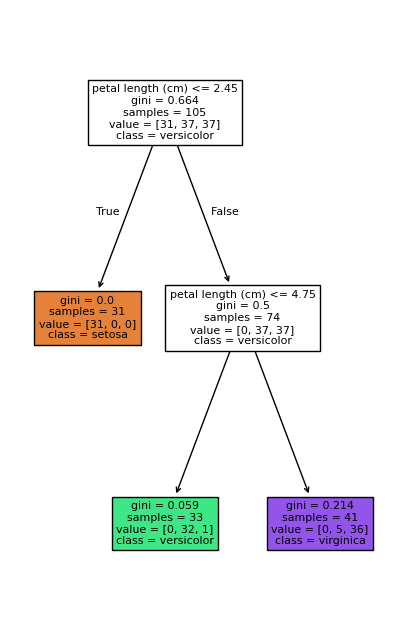

In [448]:
# Vizulization
plt.figure(figsize=(5,8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

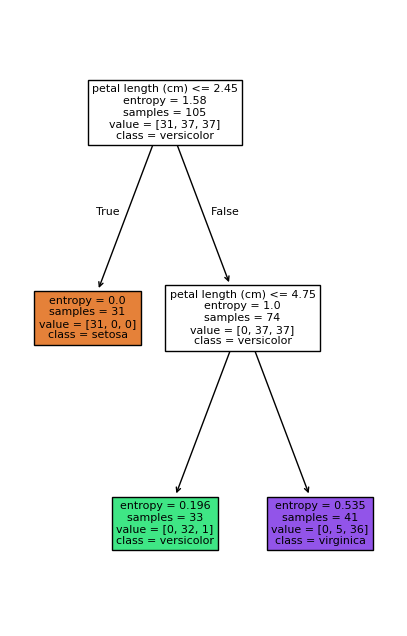

In [450]:
# Vizulize using entropy
plt.figure(figsize=(5,8))
plot_tree(
    model_entropy,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

In [290]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [292]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\Churn_Modelling (1).csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [294]:
# Data Cleaning
df['Gender']=df['Gender'].replace({'Male':0,'Female':1})

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_17188\820585778.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df['Gender'].replace({'Male':0,'Female':1})


In [298]:
# Feature election
X=df[['CreditScore','Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember','EstimatedSalary']]
y=df[['Exited']]

In [302]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [452]:
# Model Selection Decision tree
model_t5=DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

In [454]:
# Model Trannning
model_t5.fit(X_train,y_train)
pred=model.predict(X_test)

In [456]:
# Accuracy score
accuracy=accuracy_score(y_test,pred)
print("Accuracy Score:",accuracy*100)

Accuracy Score: 97.77777777777777


In [458]:
# Feature Importances
feature_model =model_t5.feature_importances_
print("Feature Importance:",feature_model)

Feature Importance: [0.01948233 0.         0.89118408 0.0893336 ]


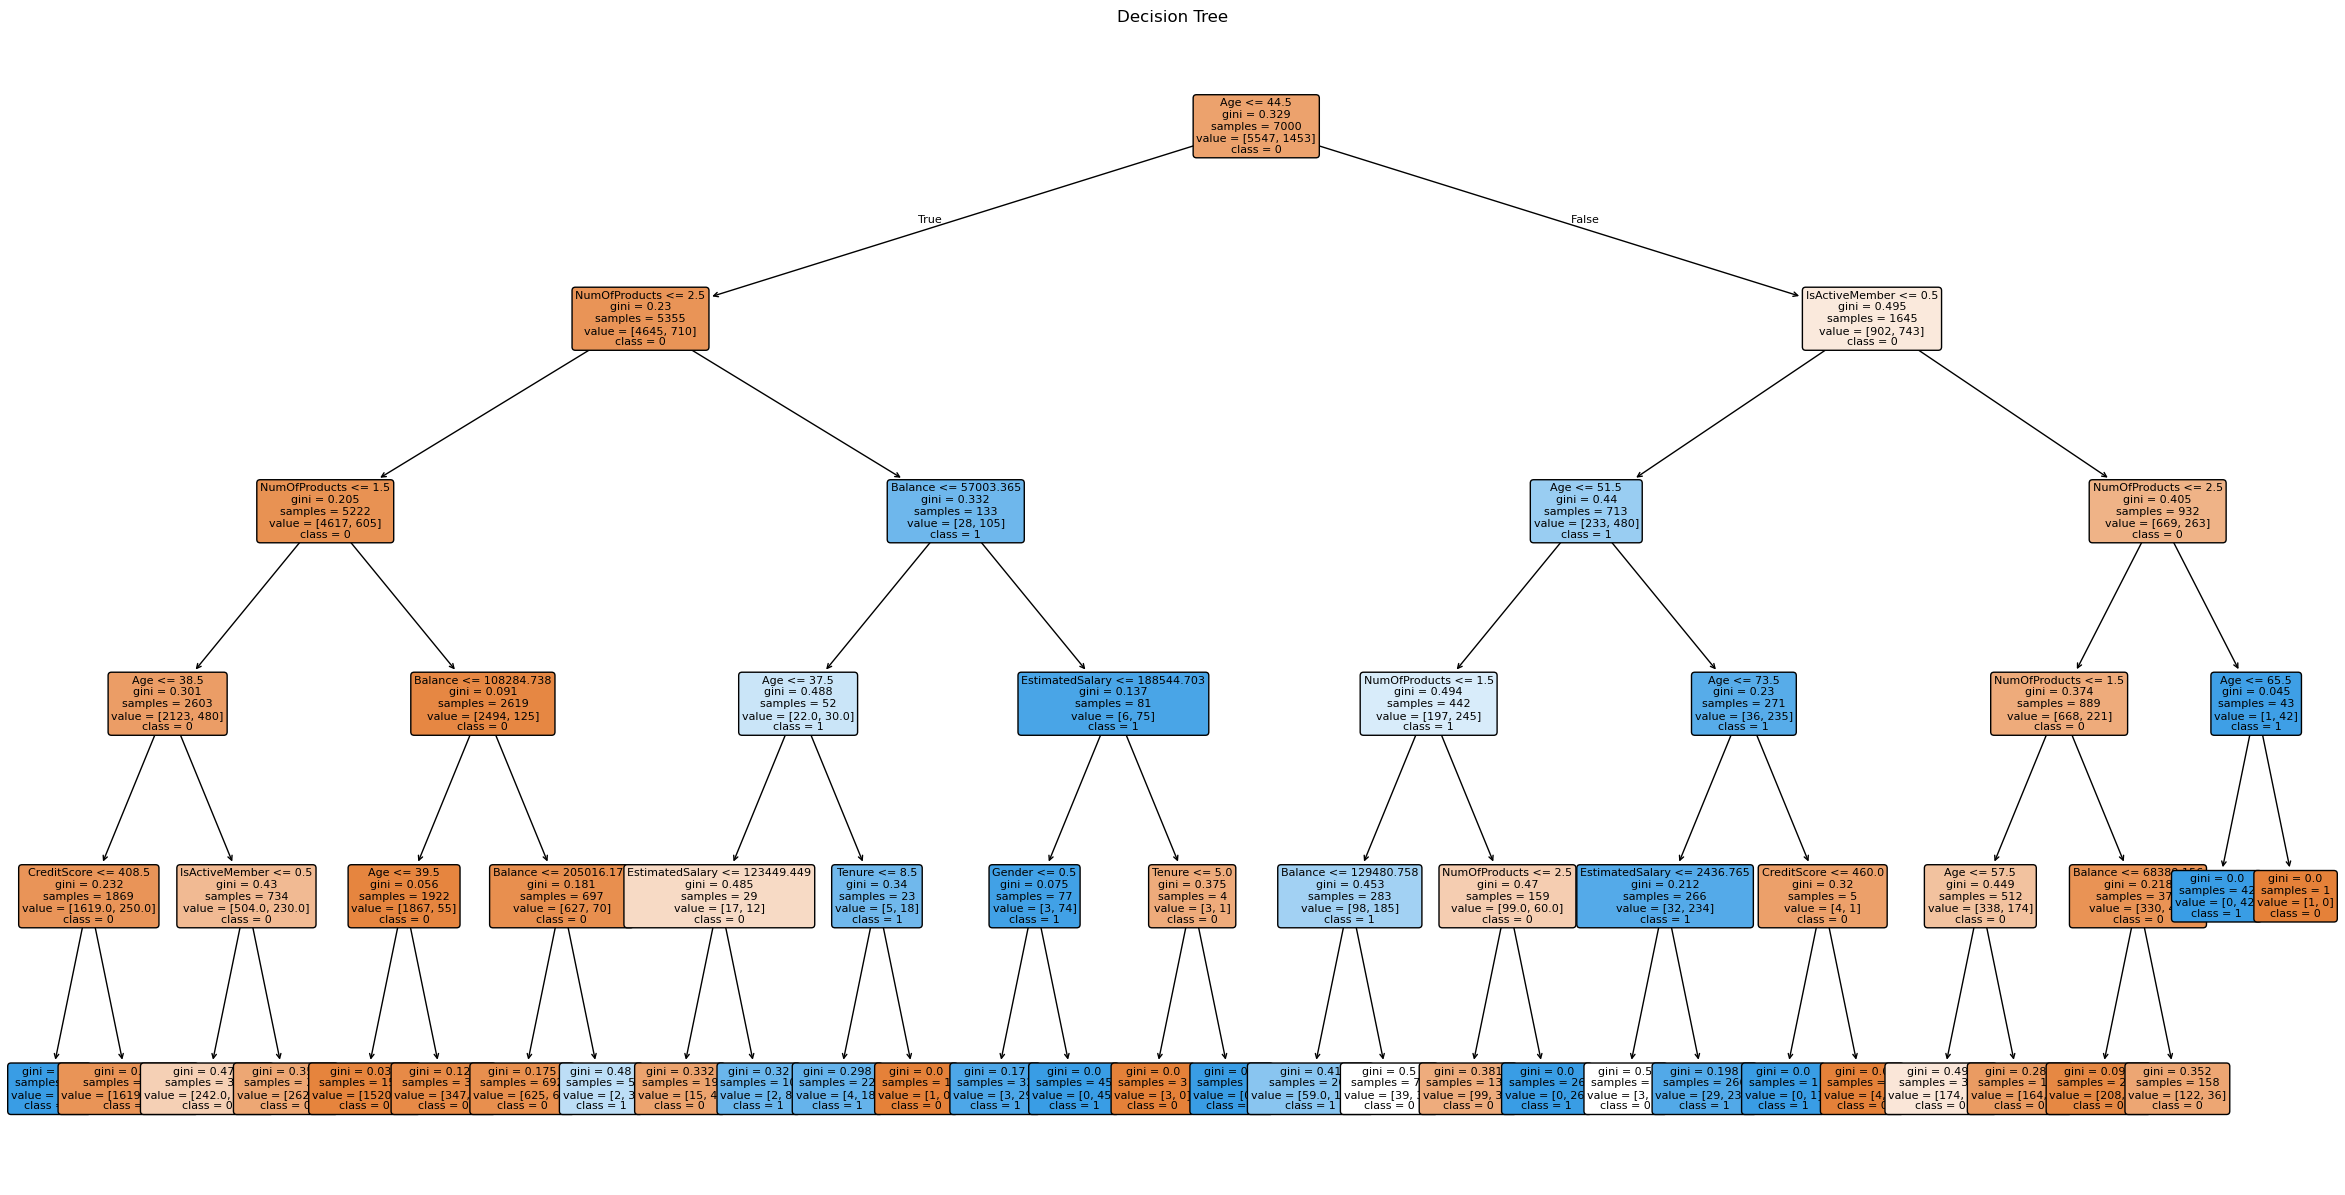

In [318]:
# Visulization for decision tree
plt.figure(figsize=(30,15))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['0','1'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree')
plt.show()

In [320]:
# Session 13

In [322]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [324]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

X = df.drop("target", axis=1)
y = df["target"]

In [326]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [368]:
# Model Selection
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [370]:
# Acuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy * 100)

Random Forest Accuracy: 75.0


In [334]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [338]:
data = {
    "price": [
        15000, 18000, 22000, 25000, 12000,
        800, 1200, 1500, 900, 1800,
        45000, 55000, 60000, 75000, 50000,
        2500, 3500, 4000, 3000, 4500
    ],
    "rating": [
        4.3, 4.5, 4.2, 4.6, 4.1,
        4.0, 4.2, 4.4, 3.9, 4.3,
        4.5, 4.7, 4.6, 4.8, 4.4,
        4.1, 4.3, 4.5, 4.0, 4.4
    ],
    "brand": [
        "Samsung", "Apple", "Samsung", "OnePlus", "Realme",
        "Puma", "Nike", "Adidas", "Puma", "Nike",
        "Sony", "LG", "Samsung", "Sony", "LG",
        "Levis", "Puma", "Nike", "Adidas", "Levis"
    ],
    "category": [
        "Mobile", "Mobile", "Mobile", "Mobile", "Mobile",
        "Shoes", "Shoes", "Shoes", "Shoes", "Shoes",
        "TV", "TV", "TV", "TV", "TV",
        "Fashion", "Fashion", "Fashion", "Fashion", "Fashion"
    ]
}

df = pd.DataFrame(data)
df

,price,rating,brand,category
0,15000,4.3,Samsung,Mobile
1,18000,4.5,Apple,Mobile
2,22000,4.2,Samsung,Mobile
3,25000,4.6,OnePlus,Mobile
4,12000,4.1,Realme,Mobile
5,800,4.0,Puma,Shoes
6,1200,4.2,Nike,Shoes
7,1500,4.4,Adidas,Shoes
8,900,3.9,Puma,Shoes
9,1800,4.3,Nike,Shoes


In [348]:
X = df[["price", "rating", "brand"]]
y = df["category"]

X = pd.get_dummies(X, columns=["brand"])

In [470]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [484]:
# Model Selection
best_accuracy = 0
for n in [10, 50, 100]:
    for depth in [2, 4, 6]:
        model_t2 = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42)
    model_t2.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(n, depth, accuracy * 100)

10 6 96.66666666666667
50 6 96.66666666666667
100 6 96.66666666666667


In [482]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 96.66666666666667


In [422]:
# Feature Importance
feature_importances_ = model_t2.feature_importances_
print("Feature Importance:",feature_importances_)

Feature Importance: [0.40418554 0.2220598  0.0347108  0.         0.04511537 0.0361799
 0.05995428 0.03934682 0.03612905 0.02883804 0.04577498 0.04770541]


In [563]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [565]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\data (1).csv")
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [567]:
df['diagnosis']=df['diagnosis'].map({'M':0,'B':1})

In [579]:
X=df[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]
y=df['diagnosis']

In [581]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.5,random_state=42)

In [583]:
# Model Selecion
model_re=RandomForestClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

In [589]:
# Model Tranning
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [593]:
# ACCuracy
accuracy=accuracy_score(y_test,y_pred)
print("Random Forest Accuracy:",accuracy*100)

Random Forest Accuracy: 95.08771929824562


In [597]:
# feature Importances
feature_importances_=model.feature_importances_
print("Feature importances:",feature_importances_)

Feature importances: [0.03939032 0.01130258 0.06532442 0.04737512 0.00488758 0.01429698
 0.08290765 0.11748225 0.00242664 0.00646696 0.01763002 0.00332555
 0.01878094 0.03616848 0.00408162 0.0061032  0.00900202 0.00460205
 0.00325346 0.00356581 0.07487754 0.01249826 0.06459085 0.1238395
 0.00916753 0.0166414  0.03300246 0.15269398 0.01019555 0.00411929]


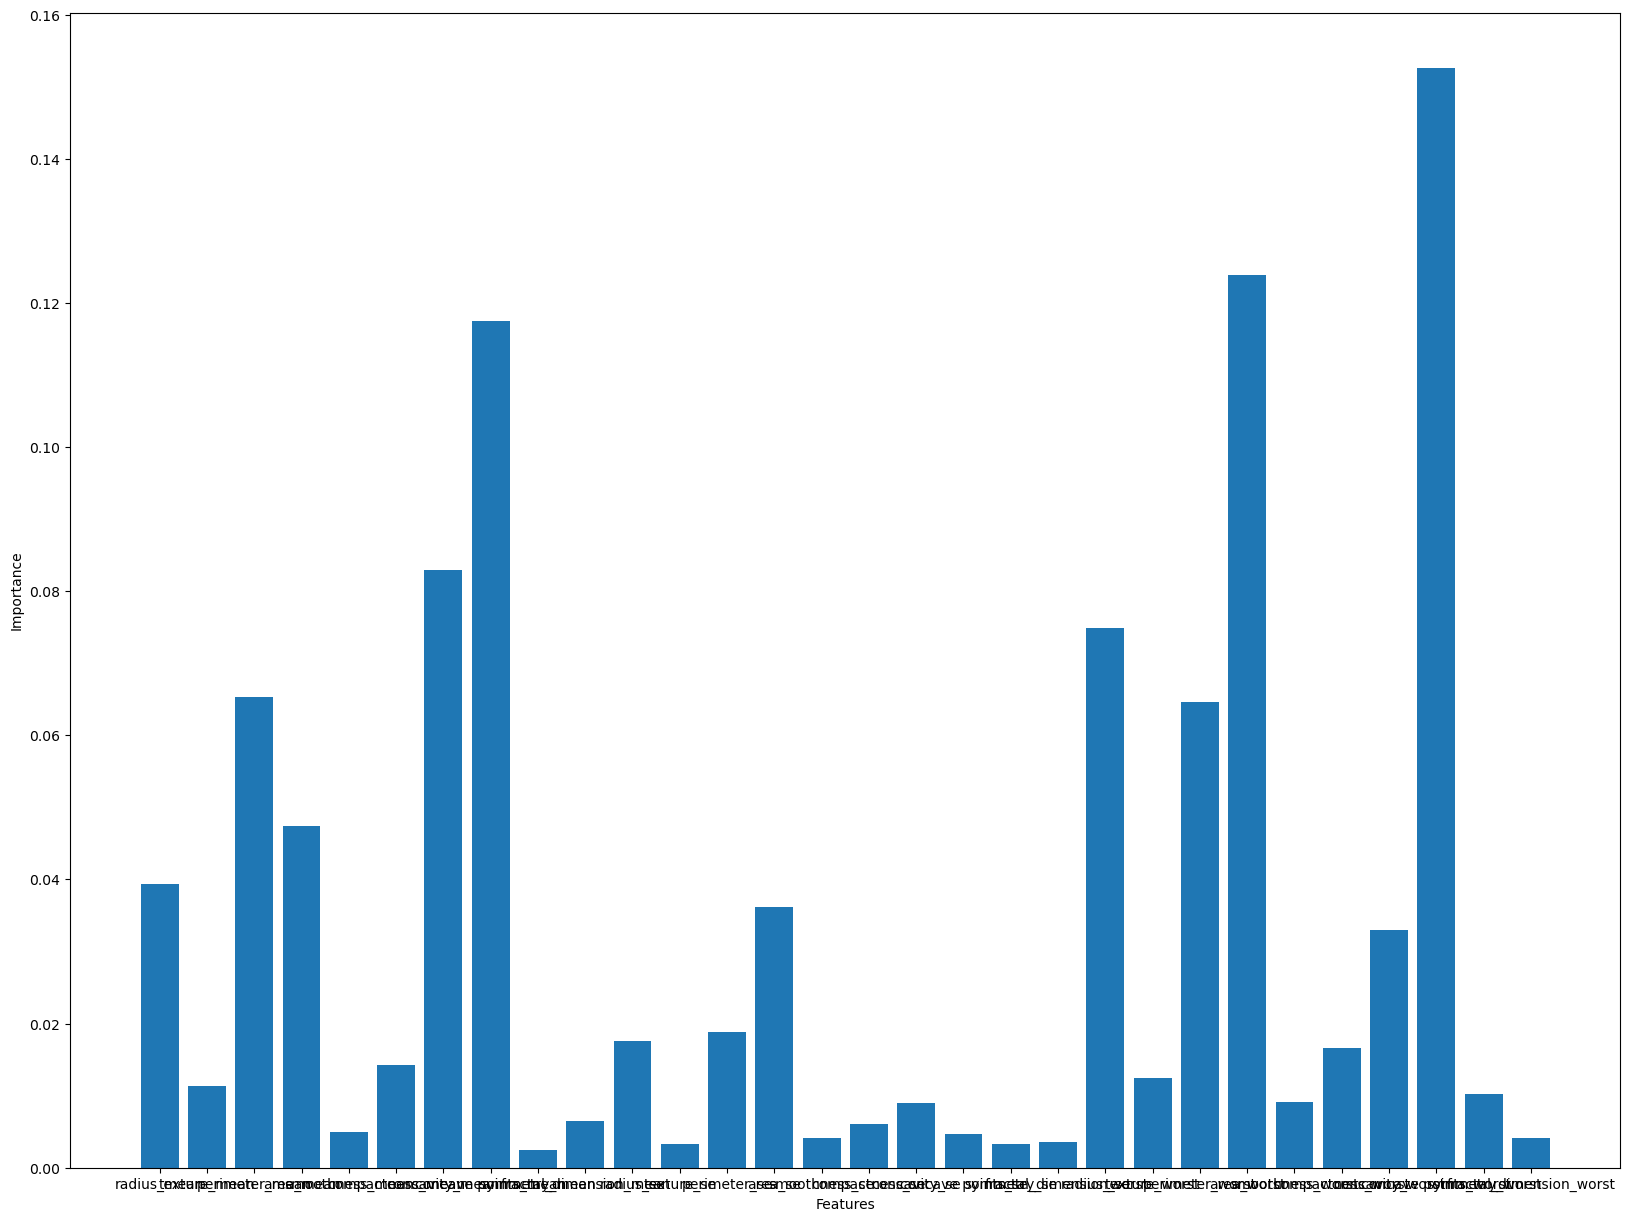

In [599]:
# Graph of feature Importances
plt.figure(figsize=(20,15))
plt.bar(
    X.columns,
    feature_importances_
)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

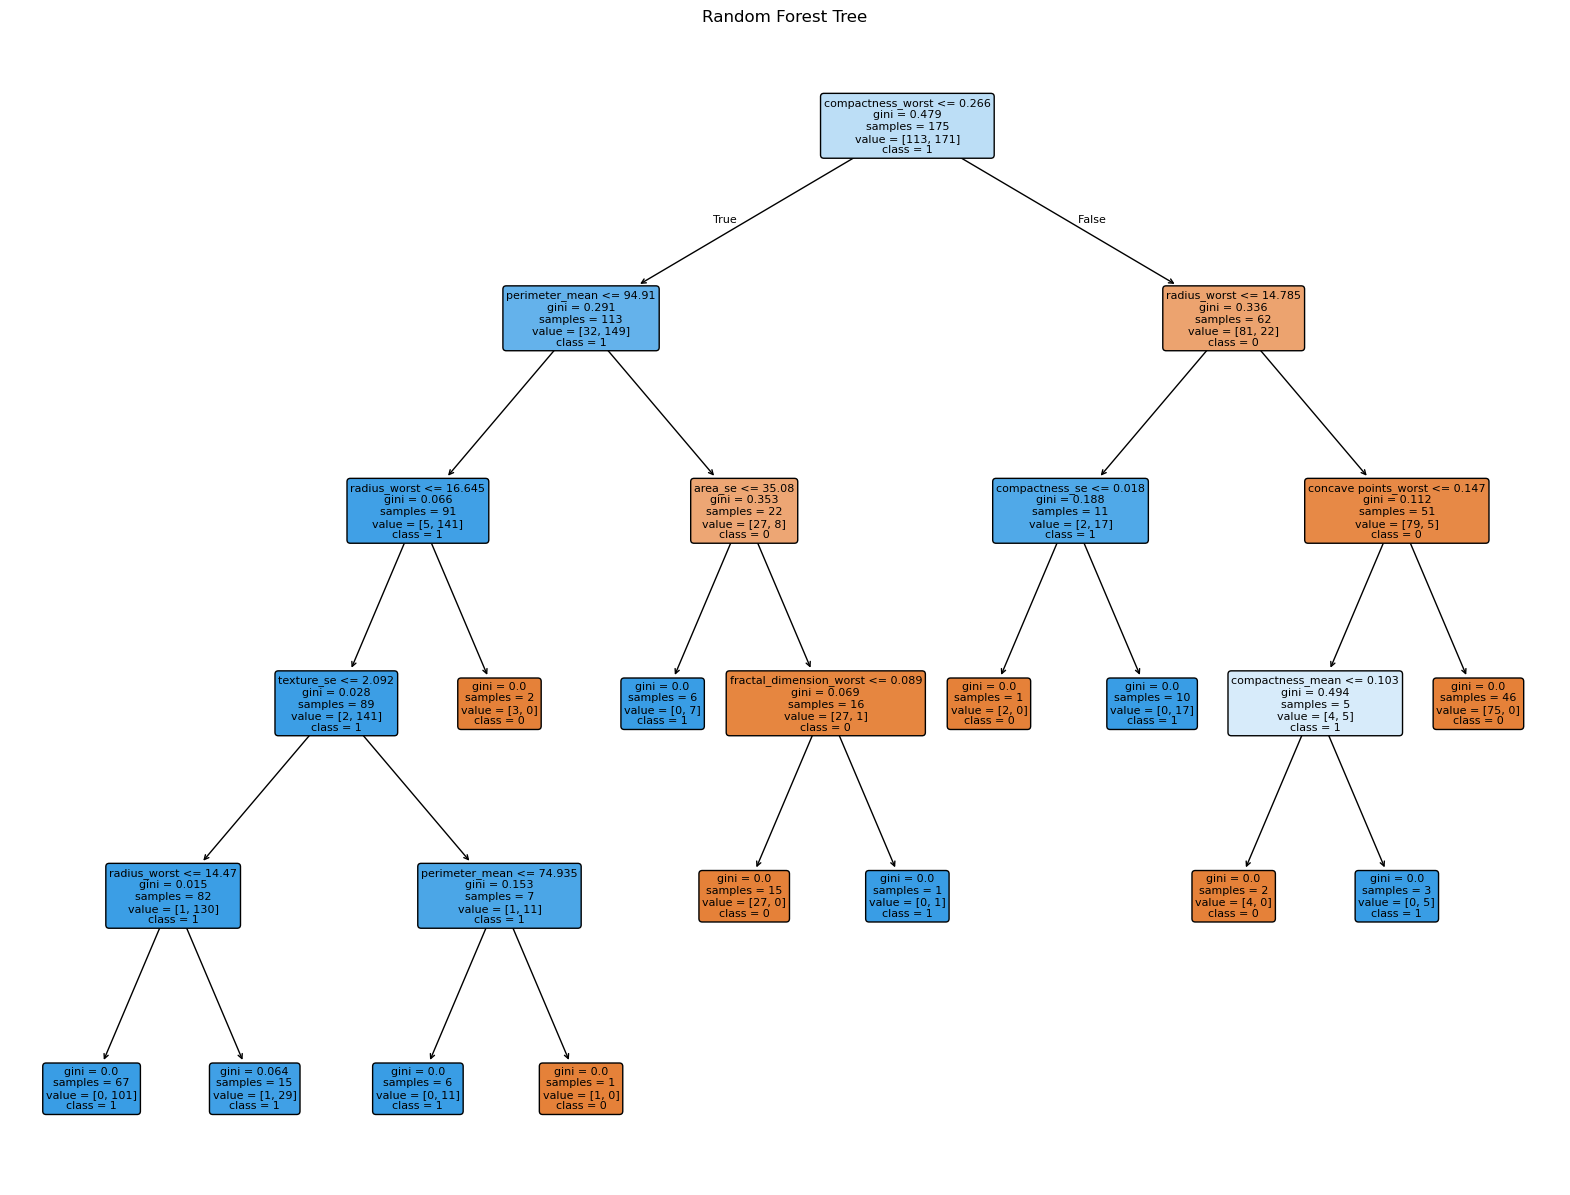

In [601]:
# Visulize random forest
plt.figure(figsize=(20,15))
plot_tree(
    model.estimators_[5],
    feature_names=X.columns,
    class_names=['0','1'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Random Forest Tree')
plt.show()